# Snapshot Tests

Refactoring started from the **devel** branch (aka comparison) creating the **devel_bse** branch (aka refactoring).
After every change the code was compiled as 
    
    make clean && make debug
    
And later the code was checked using the **test_snapshots.py**.


## test_snapshots.py

- takes a subsample of systems in the comparion snapshot
- comparing the evolution of these systems in the comparison and refactoring snaptshots for the set of parameters.
- using the **SMAPE** metric to identify differences
- for errors in the refactoring data there should be a lot of errors with many showing no data for respecitve binary in the refactoring data
- for good data there still will be **a few systems with non-zero SMAPE** which can result from numerical approximations. The SMAPE values should be small and appear in a couple of systems (e.g. 5 in 100)


In [1]:
import re
# ^^^ pyforest auto-imports - don't write above this line
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

from importlib import reload
import logging
logging.basicConfig(level='DEBUG', format='%(asctime)s|%(levelname)s|%(name)s|%(funcName)s|%(lineno)s|%(message)s')
logger = logging.getLogger()

from IPython.display import Audio,JSON

def beep():
    data = 0.1* np.sin(2*np.pi*400*np.arange(3000*2)/10000)
    display(Audio(data, rate=10000, autoplay=True, ))

from importlib import reload

import matplotlib.pyplot as plt
import seaborn as sns

import subprocess

from pathlib import Path
import json

import moccalib as ml


from time import sleep

import test_snapshots as ts

from IPython.display import clear_output

from ipydatagrid import DataGrid


chuck_workdir=Path('/work/chuck/mocca/gwiktoro/')

2023-09-19 11:06:52,508|DEBUG|matplotlib|wrapper|281|matplotlib data path: /home/gwiktoro/.local/lib/python3.10/site-packages/matplotlib/mpl-data
2023-09-19 11:06:52,517|DEBUG|matplotlib|wrapper|281|CONFIGDIR=/home/gwiktoro/.config/matplotlib
2023-09-19 11:06:52,519|DEBUG|matplotlib|<module>|1456|interactive is False
2023-09-19 11:06:52,519|DEBUG|matplotlib|<module>|1457|platform is linux
2023-09-19 11:06:52,575|DEBUG|matplotlib|wrapper|281|CACHEDIR=/home/gwiktoro/.cache/matplotlib
2023-09-19 11:06:52,584|DEBUG|matplotlib.font_manager|_load_fontmanager|1629|Using fontManager instance from /home/gwiktoro/.cache/matplotlib/fontlist-v330.json


In [2]:
snapshot_header = ml.read_header('snapshot.dat')

In [61]:
snapshot_header


,name,type,description
index,,,
1,im,INTEGER,[star/binary name (inames/inameb)]
2,r,DOUBLE,[position in the cluster in pc]
3,vr,DOUBLE,[radial velocity in km/s]
4,vt,DOUBLE,[tangential velocity in km/s]
5,u,DOUBLE,[potential [MC units]]
6,ikb,INTEGER,[binary type]
7,a,DOUBLE,[semi-major axis of a binary in Ro]
8,e,DOUBLE,[]
9,ik1,INTEGER,[star type of the first component]


In [3]:
tests = ["simple_test"]#, "ref_standev=0.0", "standev=10.0_NS", 
path_to_src = Path("$WORKDIR/devel_bse_Albrecht/src")

In [6]:
reload(ml)
p=ml.compile_mocca_remotely(path_to_src)
#print(p.stderr.decode())

MOCCA/coefpot.f:45:25:

       if(INFO) write(*,*),'coefpot  time,n,amass,smt=',
                         1
bse/interface_bse.f:3219:24:

       common /hierarchy/ mass_x,exp_r,fbMSWDMassFrac,fbMSNSMassFrac,
                        1
Mcluster/main.c: In function ‘generate_subr’:
Mcluster/main.c:3125:2: warning: implicit declaration of function ‘quick’ [-Wimplicit-function-declaration]
  quick(0, N_star-1);
  ^~~~~
Mcluster/main.c:3152:4: warning: implicit declaration of function ‘position’ [-Wimplicit-function-declaration]
    position(i, U_tot, UT_sub, S);
    ^~~~~~~~
Mcluster/main.c:3160:3: warning: implicit declaration of function ‘find_beta’ [-Wimplicit-function-declaration]
   find_beta(&maxim, &beta);
   ^~~~~~~~~
Mcluster/main.c:3187:3: warning: implicit declaration of function ‘isorand’; did you mean ‘srand’? [-Wimplicit-function-declaration]
   isorand(star2[i].v);
   ^~~~~~~
   srand
Mcluster/main.c: In function ‘get_binaries’:
Mcluster/main.c:4546:6: warning: implicit decla

In [29]:
!scp mocca:/work/chuck/mocca/gwiktoro/devel_bse_Albrecht/src/run/simple_test/system.dat system.dat


/home/gwiktoro/.bashrc: line 210: /opt/rh/devtoolset-7/enable: No such file or directory
system.dat                                      6% 6224KB  27.7KB/s   51:59 ETA^C


In [24]:
pd.read_csv('xrb.dat', sep=' ', nrows=10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,78724,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,78725,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,78724.1,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,1,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,2,Unnamed: 44,Unnamed: 45,3.4735225980097564,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,1.2439760853995960E-002,Unnamed: 55,0.42295186903586046,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,2.5463573750058810E-002,Unnamed: 65,Unnamed: 66,3.0505707289738959,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,1.1,Unnamed: 84,Unnamed: 85,Unnamed: 86,Unnamed: 87,Unnamed: 88,Unnamed: 89,Unnamed: 90,Unnamed: 91,Unnamed: 92,14,Unnamed: 94,Unnamed: 95,16.642224084361580,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103,37.474446540916219,Unnamed: 105,Unnamed: 106,Unnamed: 107,Unnamed: 108,Unnamed: 109,Unnamed: 110,Unnamed: 111,14.580480725096457,Unnamed: 113,Unnamed: 114,Unnamed: 115,Unnamed: 116,Unnamed: 117,Unnamed: 118,Unnamed: 119,9.3362899979779518E-010,Unnamed: 121,Unnamed: 122,4.4939820761667431,Unnamed: 124,Unnamed: 125,Unnamed: 126,Unnamed: 127,Unnamed: 128,Unnamed: 129,Unnamed: 130,1.5889165333348476E-004,Unnamed: 132,Unnamed: 133,29752.352369231263,Unnamed: 135,Unnamed: 136,Unnamed: 137,Unnamed: 138,Unnamed: 139,Unnamed: 140,Unnamed: 141,1.0000000000000000E-010,Unnamed: 143,Unnamed: 144,0.0000000000000000,Unnamed: 146,Unnamed: 147,Unnamed: 148,Unnamed: 149,Unnamed: 150,Unnamed: 151,Unnamed: 152,37.474446540916219.1,Unnamed: 154,Unnamed: 155,Unnamed: 156,Unnamed: 157,Unnamed: 158,Unnamed: 159,Unnamed: 160,0.0000000000000000.1,Unnamed: 162,Unnamed: 163,Unnamed: 164,Unnamed: 165,Unnamed: 166,Unnamed: 167,Unnamed: 168,1.5889165333348476E-004.1,Unnamed: 170,Unnamed: 171,1.0000000000000000E-010.1,Unnamed: 173,Unnamed: 174,1.0000000000000000E-010.2,Unnamed: 176,Unnamed: 177,1.0000000000000000E-010.3,Unnamed: 179,Unnamed: 180,1.0000000000000000E-010.4,Unnamed: 182,Unnamed: 183,2613.8638379214049,Unnamed: 185,Unnamed: 186,Unnamed: 187,Unnamed: 188,Unnamed: 189,Unnamed: 190,Unnamed: 191,200000000.00000003,Unnamed: 193,Unnamed: 194,Unnamed: 195,Unnamed: 196,Unnamed: 197,Unnamed: 198,Unnamed: 199,2.1370749760395499E-039,Unnamed: 201,Unnamed: 202,0.0000000000000000.2,Unnamed: 204,Unnamed: 205,Unnamed: 206,Unnamed: 207,Unnamed: 208,Unnamed: 209,Unnamed: 210,0.0000000000000000.3,Unnamed: 212,Unnamed: 213,Unnamed: 214,Unnamed: 215,Unnamed: 216,Unnamed: 217,Unnamed: 218,7.6052624152074606E-030,Unnamed: 220,Unnamed: 221,4.5388493820639235,Unnamed: 223,Unnamed: 224,Unnamed: 225,Unnamed: 226,Unnamed: 227,Unnamed: 228,Unnamed: 229,6.5694356678290697,Unnamed: 231,Unnamed: 232,Unnamed: 233,Unnamed: 234,Unnamed: 235,Unnamed: 236,Unnamed: 237,2.1370749760395499E-039.1,Unnamed: 239,-7.6052624152074606E-030,Unnamed: 241,Unnamed: 242,0.0000000000000000.4,Unnamed: 244,Unnamed: 245,Unnamed: 246,Unnamed: 247,Unnamed: 248,Unnamed: 249,Unnamed: 250,0.0000000000000000.5,Unnamed: 252,Unnamed: 253,Unnamed: 254,Unnamed: 255,Unnamed: 256,Unnamed: 257,Unnamed: 258,2.3990568575552726E-003
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78724,NaN,NaN,NaN,NaN,NaN,NaN,78725,NaN,NaN,NaN,NaN,NaN,NaN,78724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,3.483523,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01,NaN,0.432952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.025464,NaN,NaN,3.050571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,NaN,NaN,16.642225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.474446,NaN,NaN,NaN,NaN,

In [5]:
df = ml.read_snapshot('snapshot.dat')
df.shape

(2648516, 36)

In [14]:
df.query("mtr1>0 and mtr2>0").head()

,im,r,vr,vt,u,ikb,a,e,ik1,ik2,sm1,sm2,popId1,popId2,timenr,idd1,idd2,lum1,lum2,rad1,rad2,hist1,hist2,spin1,spin2,mu1,mu2,mv1,mv2,mb1,mb2,mi1,mi2,mtr1,mtr2,tsnap


In [13]:
df.mtr1.max()

1.4221e-07

In [15]:
def Lxacc(M, R, Mdot, k):
    
    if k==14:
        eta = 0.5
    else:
        eta = 1.0
        
    if k==14:
        R_factor = 3  # disc accretion
    else:
        R_factor = 1
    
    return 1.2e41 * eta * M * Mdot / (R_factor * R)  # erg/s

In [18]:
df['Lx1']=df.apply(lambda row: Lxacc(row.sm1, row.rad1, row.mtr1, row.ik1), axis=1)
df['Lx2']=df.apply(lambda row: Lxacc(row.sm2, row.rad2, row.mtr2, row.ik2), axis=1)

/tmp/ipykernel_618328/514892571.py:13: RuntimeWarning: invalid value encountered in double_scalars
  return 1.2e41 * eta * M * Mdot / (R_factor * R)  # erg/s


In [19]:
df['Lx']=df[['Lx1','Lx2']].max(axis=1)

In [20]:
df.query('mtr1>0 or mtr2>0').head()

,im,r,vr,vt,u,ikb,a,e,ik1,ik2,sm1,sm2,popId1,popId2,timenr,idd1,idd2,lum1,lum2,rad1,rad2,hist1,hist2,spin1,spin2,mu1,mu2,mv1,mv2,mb1,mb2,mi1,mi2,mtr1,mtr2,tsnap,Lx1,Lx2,Lx
55918,54879,0.82309,-3.02870,6.7700,-1.3833,1,118.9500,4.330500e-06,7,1,1.3472,12.7220,2,2,50,107006,107007,791.310000,21688.00,0.279240,5.1776,0,300,4.671800e-01,2396.00,0.99572,-4.2758,2.5016,-2.95800,2.1685,-3.24340,2.8261,-2.667800,-1.692000e-10,8.668500e-13,50,-9.795713e+31,2.555948e+29,2.555948e+29
56439,54931,0.97411,1.45760,6.5221,-1.3644,1,24.0200,5.777100e-05,12,1,1.0262,7.2705,2,2,50,107110,107111,0.027283,4906.40,0.007762,4.5182,900,600,2.125300e+04,910.96,10.13500,-3.1073,11.3360,-2.02520,11.2110,-2.25560,11.6150,-1.796600,1.031400e-12,-3.093600e-10,50,1.636335e+31,-5.973711e+31,1.636335e+31
57178,40354,1.13950,0.55024,4.9798,-1.3426,1,6.0649,2.479600e-07,7,1,1.4096,5.4669,1,1,50,77956,77957,1118.000000,1338.30,0.310650,2.7530,0,900,4.797800e-02,3420.90,0.72433,-1.7995,2.2360,-0.80033,1.9010,-1.01100,2.5624,-0.586890,-2.841400e-10,4.757900e-11,50,-1.547170e+32,1.133787e+31,1.133787e+31
58428,54885,1.37510,7.17230,10.1500,-1.3091,1,105.8200,2.445800e-02,7,1,1.4399,11.0650,2,2,50,107018,107019,1463.200000,11818.00,0.323280,4.0849,0,900,4.093600e+02,1918.00,0.58060,-3.6368,2.1006,-2.35230,1.7628,-2.63050,2.4298,-2.067000,-4.254600e-10,2.419700e-12,50,-2.274016e+32,7.865254e+29,7.865254e+29
59006,54933,1.47520,-77.37400,65.4880,-1.2939,1,42.3000,6.696800e-01,13,1,1.1079,4.4033,2,2,50,107114,107115,0.000061,554.46,0.000014,2.1828,0,900,2.000000e+08,1076.40,21.46000,-1.0036,23.1160,-0.10814,22.7330,-0.29606,23.4910,0.084409,-3.691200e-21,1.032000e-31,50,-3.505269e+25,2.498189e+10,2.498189e+10


In [21]:
df.Lx.max()

7.926652800000002e+37

In [7]:
  
ml.moccarun_remotely(path_to_src / 'run' / tests[0])

CompletedProcess(args="ssh chuck 'cd $WORKDIR/devel_bse_Albrecht/src/run/simple_test && moccarun'", returncode=0, stdout=b'Group quota on /work/chuck (beegfs):\n      user/group     ||           size          ||    chunk files    \n     name     |  id  ||    used    |    hard    ||  used   |  hard   \n--------------|------||------------|------------||---------|---------\n           dyn|  5009||   83.92 TiB|  150.00 TiB||  6640477| 10000000\nSubmitted batch job 1555453\n', stderr=b'')

In [4]:
reload(ml)
ml.logger.setLevel('DEBUG')
snapshot0 = path_to_src / "run/pretest/snapshot.dat"
snapshot1 = path_to_src / "run/simple_test/snapshot.dat"
ml.compare_snapshots_on_chuck(snapshot0, snapshot1)

Group quota on /work/chuck (beegfs):
      user/group     ||           size          ||    chunk files    
     name     |  id  ||    used    |    hard    ||  used   |  hard   
--------------|------||------------|------------||---------|---------
           dyn|  5009||   84.54 TiB|  150.00 TiB||  6813631| 10000000


2023-09-19 11:12:56,476|INFO|__main__|<module>|65|Loading snapshots
/home/gwiktoro/.pyenv/versions/3.9.16/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:383: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)
/home/gwiktoro/.pyenv/versions/3.9.16/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:383: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)
2023-09-19 11:13:10,144|INFO|__main__|<module>|70|snapshot0.shape=(165536, 36); snapshot1.shape=(165536, 36)
2023-09-19 11:13:10,147|INFO|__main__|<module>|71|snapshot0.im.nunique()=55284
2023-09-19 11:13:10,150|INFO|__main__|<module>|81|len(im_l)=1000
2023-09-19 11:13:24,617|INFO|__main__|<module>|99|ALL GOOD!


CompletedProcess(args="ssh chuck 'test_snapshots.py $WORKDIR/devel_bse_Albrecht/src/run/pretest/snapshot.dat  $WORKDIR/devel_bse_Albrecht/src/run/simple_test/snapshot.dat --n-systems=1000'", returncode=0)

In [4]:
reload(ml)

def mocca_compare(path_to_src, path_to_src_cmp, do_compilation=True):
    
    if do_compilation:
        logger.info("Compilation")
        p_compilation = ml.compile_mocca_remotely(path_to_src)
        if p_compilation.returncode != 0:
            logger.error(f"{p_compilation.returncode=}\n{p_compilation.stderr.decode()}")
            return None

    logger.info("Starting jobs")
    jobs=[]
    for test in tests:
        # Command to execut on chuck
        # should be a one line string to be executed with ssh, so not using multi-line string
        chuck_cmd = (
            f" cd {path_to_src}/run/{test}/ && "
            f" moccarun"  # new code compilation

    #        f"   --n-systems 100 "
        )

        p = subprocess.run(f"ssh chuck '{chuck_cmd}'", shell=True, stdout=subprocess.PIPE)
        jobId = int(re.search("Submitted batch job (?P<jobId>\d+)", p.stdout.decode()).group('jobId'))
        logger.debug(f"{test=}; {jobId=}")
        
        jobs.append({'test':test, 'jobId':jobId})
        
    while len(jobs) > 0:
        # clear_output(wait=True)
        df = ml.squeue_chuck().query(f"JOBID in {[job['jobId'] for job in jobs]}")
        # print(pd.Timestamp.now())
        # display(df)
        jobs_running = df.JOBID.values.tolist()

        for job in jobs:
            if int(job['jobId']) not in jobs_running:
                logger.info(f"TESTING: {job}")
                chuck_cmd = (
                    f" cd {path_to_src}/run/{test}/ && "
                    f" $WORKDIR/refactoring/test_snapshots.py "
                    f"   --refactoring-snapshot snapshot.dat "
                    f"   --comparison-snapshot {path_to_src_cmp}/run/{test}/snapshot.dat "
                   f"   --n-systems 1000 "
                )

                p = subprocess.run(f"ssh chuck '{chuck_cmd}'", shell=True, stdout=subprocess.PIPE)

        jobs = [job for job in jobs if int(job['jobId']) in jobs_running]
        sleep(10)


Group quota on /work/chuck (beegfs):
      user/group     ||           size          ||    chunk files    
     name     |  id  ||    used    |    hard    ||  used   |  hard   
--------------|------||------------|------------||---------|---------
           dyn|  5009||   76.21 TiB|  150.00 TiB||  6777030| 10000000


CompletedProcess(args="ssh chuck 'scancel 1507744 1507743 1510139'", returncode=0)

In [8]:
# cancel all jobs
jobids = ml.squeue_chuck()['JOBID'].values.tolist()
exec_remotely(f"scancel -u gwiktoro {' '.join(map(str,jobids))}")

Group quota on /work/chuck (beegfs):
      user/group     ||           size          ||    chunk files    
     name     |  id  ||    used    |    hard    ||  used   |  hard   
--------------|------||------------|------------||---------|---------
           dyn|  5009||   75.13 TiB|  150.00 TiB||  6769352| 10000000


CompletedProcess(args="ssh chuck 'scancel -u gwiktoro 1494334 1494333 1494332 1494331 1494330 1494329 1494328 1494327 1494326'", returncode=0)

In [6]:
mocca_compare(
    "$WORKDIR/refactoring/devel_bse_Albrecht/src", "$WORKDIR/refactoring/devel/src"
)`
        
beep()
!notify-send "Test finished!"

2023-06-14 14:36:19,265|INFO|root|mocca_compare|6|Compilation
2023-06-14 14:36:21,973|ERROR|root|mocca_compare|9|p_compilation.returncode=2
MOCCA/coefpot.f:45:25:

       if(INFO) write(*,*),'coefpot  time,n,amass,smt=',
                         1
MOCCA/input.f:821:35:

       call config_getint(rcore_HeGB, 0, key, conf);
                                   1
Error: Symbol ‘rcore_hegb’ at (1) has no IMPLICIT type
MOCCA/input.f:813:35:

       call config_getint(rcore_HeHG, 0, key, conf);
                                   1
Error: Symbol ‘rcore_hehg’ at (1) has no IMPLICIT type
MOCCA/input.f:797:34:

       call config_getint(rcore_RGB, 0, key, conf);
                                  1
Error: Symbol ‘rcore_rgb’ at (1) has no IMPLICIT type
MOCCA/input.f:805:36:

       call config_getint(rcore_TPAGB, 0, key, conf);
                                    1
Error: Symbol ‘rcore_tpagb’ at (1) has no IMPLICIT type
make: *** [<builtin>: MOCCA/input.o] Error 1



In [15]:
!scp chuck:/work/chuck/mocca/gwiktoro/refactoring/devel_no_more_gotos/src/xrb.dat .

Group quota on /work/chuck (beegfs):


In [3]:
p = compare_snapshots_on_chuck('/work/chuck/mocca/gwiktoro/refactoring/devel_bse_Albrecht/src/run/pretest/snapshot.dat', '/work/chuck/mocca/gwiktoro/refactoring/devel_bse_Albrecht/src/run/rcore_tests/snapshot.dat')

2023-07-22 09:22:26,428|INFO|__main__|<module>|77|Loading snapshots
/home/gwiktoro/.pyenv/versions/3.9.16/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:383: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)
2023-07-22 09:22:27,687|INFO|__main__|<module>|82|snapshot_refactoring.shape=(16568, 36); snapshot_comparison.shape=(16574, 36)
2023-07-22 09:22:27,688|INFO|__main__|<module>|83|snapshot_refactoring.im.nunique()=5536
2023-07-22 09:22:27,689|INFO|__main__|<module>|91|len(im_l)=1000
2023-07-22 09:22:30,772|WARNING|__main__|<module>|100|SMAPE is nonzero!
       smape        mean_0         std_0        mean_1         std_1
0   0.000000  2.000000e+00  1.414214e+00  2.000000e+00  1.414214e+00
1   0.000000  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
2   0.000000  4.931533e+00  1.932759e-02  4.931533e+00  1.932759e-02
3   0.000000  2.255400e-01  0.000000e+00  2.255400e-01  0.000000e+00
4   0.000000  3.662233e+05  1.376501e+03  

In [54]:
test0 = "pretest"
test1 = "rcore_pretest"
p = compare_snapshots_on_chuck(f'/work/chuck/mocca/gwiktoro/refactoring/devel_bse_Albrecht/src/run/{test0}/snapshot.dat', f'/work/chuck/mocca/gwiktoro/refactoring/devel_bse_Albrecht/src/run/{test1}/snapshot.dat', n_systems=6000)

2023-07-25 15:23:57,457|INFO|__main__|<module>|65|Loading snapshots
/home/gwiktoro/.pyenv/versions/3.9.16/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:383: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)
/home/gwiktoro/.pyenv/versions/3.9.16/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:383: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)
2023-07-25 15:24:11,203|INFO|__main__|<module>|70|snapshot0.shape=(165544, 36); snapshot1.shape=(165544, 36)
2023-07-25 15:24:11,206|INFO|__main__|<module>|71|snapshot0.im.nunique()=55287
2023-07-25 15:24:11,209|INFO|__main__|<module>|81|len(im_l)=55287
2023-07-25 15:36:56,097|INFO|__main__|<module>|99|ALL GOOD!


- amend the git commit message before get_new_ages to mark that it introduced small changes
- change branch name for refactoring
- cvcheck()

In [49]:
ml.exec_remotely("cd /work/chuck/mocca/gwiktoro/refactoring/devel_bse_Albrecht/src && moccatest.py --test-name posttest --compile --do-snapshot-test run/pretest/snapshot.dat")

beep()

Group quota on /work/chuck (beegfs):
      user/group     ||           size          ||    chunk files    
     name     |  id  ||    used    |    hard    ||  used   |  hard   
--------------|------||------------|------------||---------|---------
           dyn|  5009||   78.00 TiB|  150.00 TiB||  6798184| 10000000
rm --f *.o ./fewbody//*.o ./MOCCA//*.o ./utils//*.o ./bse//*.o ./kdtree2//*.o ./iniparser//*.o ./marsene//*.o ./sevn/lib/base//*.o ./sevn/lib/utils//*.o ./columns//*.o ./bse/ffbonn//*.o ./sevn/*.o ./sevn/src/utils/*.o \
	./Mcluster/*.o ./Mcluster/jeans.h ./sevn/src/base/*.o *.mod \
	./kdtree2/*.mod \
	mocca moccatest standalone_single standalone_binary startrack.err
rm -rf ./ffbonn/ 


MOCCA/coefpot.f:45:25:

       if(INFO) write(*,*),'coefpot  time,n,amass,smt=',
                         1
bse/interface_bse.f:3210:24:

       common /hierarchy/ mass_x,exp_r,fbMSWDMassFrac,fbMSNSMassFrac,
                        1
bse/evolv2b.f:185:72:

      &      ospin, dmt, dmr, rol, dmdt)
                                                                        1
Mcluster/main.c: In function ‘generate_subr’:
Mcluster/main.c:3125:2: warning: implicit declaration of function ‘quick’ [-Wimplicit-function-declaration]
  quick(0, N_star-1);
  ^~~~~
Mcluster/main.c:3152:4: warning: implicit declaration of function ‘position’ [-Wimplicit-function-declaration]
    position(i, U_tot, UT_sub, S);
    ^~~~~~~~
Mcluster/main.c:3160:3: warning: implicit declaration of function ‘find_beta’ [-Wimplicit-function-declaration]
   find_beta(&maxim, &beta);
   ^~~~~~~~~
Mcluster/main.c:3187:3: warning: implicit declaration of function ‘isorand’; did you mean ‘srand’? [-Wimplicit-function-declaration

Submitted batch job 1526178


2023-07-25 11:17:40,374|INFO|__main__|<module>|65|Loading snapshots
/home/gwiktoro/.pyenv/versions/3.9.16/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:383: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)
/home/gwiktoro/.pyenv/versions/3.9.16/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:383: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)
2023-07-25 11:17:41,501|INFO|__main__|<module>|70|snapshot0.shape=(16568, 36); snapshot1.shape=(16568, 36)
2023-07-25 11:17:41,502|INFO|__main__|<module>|71|snapshot0.im.nunique()=5536
2023-07-25 11:17:41,502|INFO|__main__|<module>|81|len(im_l)=5536
2023-07-25 11:18:58,976|INFO|__main__|<module>|99|ALL GOOD!


In [2]:
import pandas as pd

In [3]:
df = pd.DataFrame(iris['data'])

In [4]:
from tkinter import *
from pandastable import Table

In [6]:
filename = 'tmp_

AttributeError: 'DataFrame' object has no attribute 'tk'

In [7]:
pip install ipydatagrid

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 7.3 MB/s eta 0:00:008.3 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.2 MB/s eta 0:00:00m eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [32]:
# running long tests
long_tests = ["standev=10.0_long"]#
for test in long_tests:
    chuck_cmd = (
            f" cd $WORKDIR/refactoring/devel_bse/src/run/{test}/ && "
            f" $WORKDIR/refactoring/test_snapshots.py "
            f"   --refactoring-snapshot snapshot.dat "
            f"   --comparison-snapshot ../../../../devel/src/run/{test}/snapshot.dat "
            f"   --n-systems 100 "
        )

    p = subprocess.run(f"ssh chuck '{chuck_cmd}'", shell=True, stdout=subprocess.PIPE)

2023-04-01 07:23:50,948|INFO|__main__|<module>|77|Loading snapshots
Traceback (most recent call last):
  File "/work/chuck/mocca/gwiktoro//refactoring/test_snapshots.py", line 78, in <module>
  File "/work/chuck/mocca/gwiktoro/refactoring/moccalib.py", line 125, in read_snapshot
MemoryError


In [5]:
datagrid = DataGrid(df)
datagrid

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

In [ ]:
!apt install jupyterlab_widgets

In [21]:
    jobId = re.search("Submitted batch job (?P<jobId>\d+)", p.stdout.decode()).group('jobId')
    print(f"{jobId=}")

<IPython.core.display.Javascript object>

jobId='1471891'


In [28]:
p.stdout.decode()

'Group quota on /work/chuck (beegfs):\n      user/group     ||           size          ||    chunk files    \n     name     |  id  ||    used    |    hard    ||  used   |  hard   \n--------------|------||------------|------------||---------|---------\n           dyn|  5009||   51.03 TiB|  150.00 TiB||  6645074| 10000000\n INFO MOCCA version d3a02102fac7d2eb86a3092a460f9f5c1bb31b0b\n WARNING: key extra:utbse from mocca.ini is not recognized! Check the file mocca.ini for errors.\n WARNING: It was expected to read 149 keys, but actually only 141 were read\n INFO Total number of objects          400\n WARNING forcing dynamics == 0\n au2rsun   215.09705248000000      rsun2au   4.6490641711279665E-003 au2rsun*rsun2au  0.99999999999999989      andBefore  0.99999996319087869      pc2au   206264.80624547999     \n  reading the initial data from the files\n ixb,nbb,nbin3,ntt,smt=         380         380         380         400   597.01067058000024     \n sx_mcl,sv_mcl,mc2pcO,rh,rtide =   1.00000

In [24]:
subprocess.run(f"""ssh chuck 'squeue -u gwiktoro'""", shell=True)

Group quota on /work/chuck (beegfs):
      user/group     ||           size          ||    chunk files    
     name     |  id  ||    used    |    hard    ||  used   |  hard   
--------------|------||------------|------------||---------|---------
           dyn|  5009||   51.04 TiB|  150.00 TiB||  6645074| 10000000
             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)


CompletedProcess(args="ssh chuck 'squeue -u gwiktoro'", returncode=0)

In [26]:
subprocess.run(f"""ssh chuck 'sacct -j 1471891 -o jobid,state'""", shell=True)

Group quota on /work/chuck (beegfs):
      user/group     ||           size          ||    chunk files    
     name     |  id  ||    used    |    hard    ||  used   |  hard   
--------------|------||------------|------------||---------|---------
           dyn|  5009||   51.04 TiB|  150.00 TiB||  6645074| 10000000
       JobID      State 
------------ ---------- 
1471891       COMPLETED 
1471891.bat+  COMPLETED 
1471891.ext+  COMPLETED 


CompletedProcess(args="ssh chuck 'sacct -j 1471891 -o jobid,state'", returncode=0)

| file | DONE | Notes |
| :- | -: | :-: |
| circularizationsynchronizationcalculation.f | Y | circsync(); the wrapping if moved outside of the routine
| contactevolution.f | Y | contactevol()
| cvcheck.f | Y | one function was different in the code- marked with CVCHECK
| cvdeflate.f | Y | only one code snipped include as the other was significantly different
| cvinflate.f | Y |
| degrcalculation.f |  | degrcalc; inside evolv2detached; not sure how to implement
| evolv1single.f | NO | cuts `if block` in two!
| evolv2detached.f | Y | evolvdetached()
| evolv2semidetached.f | Y |
| grcalculation.f | NO | grcalc; code significantly different than in the current version
| initialize.f | NO | variables need to initialiezed in the current scope any way
| kickdetachedcalculation.f | Y | kickdetached()
| mbcalculation.f | NO | code differes
| mbcheck.f | NO | mbapply variable not present in original code
| mbrecipe.f | NO | no clear code to wrap
| mbtauconv.f | NO | should be in mbrecipe
| msunstevolution.f | Y | msunstevolv()
| mtcalculation.f | Y | mtcalc; goto135_flag added
| mtcheck.f | Y |
| nsspincalculation.f | Y | nsspincalc()
| spincalculation.f | Y |  the do loop included in subroutine for cleaner code
| wdmtcalculation.f | Y | wdmtcalc()
| wdunstevolution.f | Y | wdunstevolv()
| windaccretion.f |  | windacc(); changed to subroutine as it changes external variables

In [35]:
from astropy import units as u
from astropy.constants import G


mass_1 = 0.5*u.Msun  # mass of first object in solar masses
mass_2 = 0.5*u.Msun  # mass of second object in solar masses
period = 365*u.day  # period in days

separation = ((G*(mass_1+mass_2)*period**2)/(4*np.pi**2))**(1/3)

print(f"The binary separation is {separation.to(u.AU):.2f}.")

The binary separation is 1.00 AU.


## Send files to chuck

In [2]:
%%bash
cd /home/gwiktoro/camk/mocca-evolv2b-refactoring/src && rsync -avzt --delete --exclude '*.dat' --exclude '*.o' --exclude '*.mod' --exclude '*.h' . camk:/work/chuck/mocca/gwiktoro/mocca-evolv2b-refactoring/src/ 


sending incremental file list
deleting mocca
deleting .makefile-debug.swp
./
fort.80
makefile-debug
restart.fil
deleting bse/.update_some_binary_parameters.f.swp
deleting bse/.update_properties_singleANDdetached.f.swp
deleting bse/.update_orbital_parameters_for_detached.f.swp
deleting bse/.update_disrupted_single.f.swp
deleting bse/.interpolate_back_in_time.f.swp
deleting bse/.get_spin_for_single.f.swp
deleting bse/.get_new_ages.f.swp
deleting bse/.get_massloss_for_single.f.swp
deleting bse/.evolv2b.f.swp
deleting bse/.do_compact_merger.f.swp
zzz
MOCCA/
MOCCA/version.f
Mcluster/
bse/
bse/circsync.f
bse/contactevolv.f
bse/cvdeflate.f
bse/cvinflate.f
bse/do_common_envelope_evolution
bse/do_common_envelope_evolution.f
bse/do_compact_merger.f
bse/evolv2b.f
bse/evolv2b_funcs.f
bse/evolv2semidetached.f
bse/evolvdetached.f
bse/evolvsingle.f
bse/get_massloss_for_single.f
bse/get_new_ages.f
bse/get_spin_for_single.f
bse/initialize.f
bse/interpolate_back_in_time.f
bse/kickdetached.f
bse/msunstev

## Test files on chuck

In [3]:
!ssh camk 'ssh chuck "cd $WORKDIR && ./test_refactoring.sh"' > /dev/null

# !zenity --warning --text "MOCCA test finished!"
beep()

STOP time/tphys > tcrit
2023-02-10 08:06:44,823|INFO|__main__|<module>|77|Loading snapshots
/home/gwiktoro/.pyenv/versions/3.9.16/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:380: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)
/home/gwiktoro/.pyenv/versions/3.9.16/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:380: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)
2023-02-10 08:08:18,432|INFO|__main__|<module>|82|snapshot_refactoring.shape=(768246, 38); snapshot_comparison.shape=(768246, 38)
2023-02-10 08:08:18,440|INFO|__main__|<module>|83|snapshot_refactoring.im.nunique()=154
2023-02-10 08:08:21,451|INFO|__main__|<module>|105|ALL GOOD!


## Commiting changes from chuck

In [32]:
commit_message = "finished refactoring - a few comments left for future work"
push = True

subprocess.run(f"""ssh camk 'cd $WORKDIR/mocca-evolv2b-refactoring/src \
&& git commit --amend -am "{commit_message}" """ \
               + ("&& git push'" if push else "'"),
               shell=True
              )

[gwiktoro-evolv2b-refactoring a06eaf52] finished refactoring - a few comments left for future work
 Date: Wed Feb 8 21:35:36 2023 +0100
 3 files changed, 6 insertions(+), 772 deletions(-)


To hypki.net:mocca.git
 ! [rejected]          gwiktoro-evolv2b-refactoring -> gwiktoro-evolv2b-refactoring (non-fast-forward)
error: failed to push some refs to 'git@hypki.net:mocca.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


CompletedProcess(args='ssh camk \'cd $WORKDIR/mocca-evolv2b-refactoring/src && git commit --amend -am "finished refactoring - a few comments left for future work" && git push\'', returncode=1)

In [72]:
####
# DEPRICATED!  -> use test_refactoring on chuck
####

%%time
p = subprocess.run("""ssh camk 'ssh chuck "cd $WORKDIR && cd mocca-evolv2b-refactoring/src && make clean && make -f makefile-debug && ./mocca > zzz"'""", 
                   shell=True, 
                   stdout=subprocess.PIPE, 
                   text=True)

if p.returncode==0:
    subprocess.run("""./test_snapshots.py --n-system 100 --download Refactoring""", shell=True)

#!notify-send -u 'normal' -i /home/gwiktoro/Downloads/quantiles_equal_ranges_comparison.png "MOCCA test finished"
!zenity --warning --text "MOCCA test finished!"
beep()

bse/evolv2b.f:1667.72:

         rad(k) = rm                                                    
                                                                        1
Error: Unexpected STATEMENT FUNCTION statement at (1)
bse/evolv2b.f:1649.10:

     & rol)                                                             
          1
Error: Symbol 'rol' at (1) has no IMPLICIT type
bse/evolv2b.f:1508.15:

         roldMZ = rm                                                    
               1
Error: Symbol 'roldmz' at (1) has no IMPLICIT type
bse/evolv2b.f:1600.72:

               goto 135                                                 
                                                                        1
Error: Label 135 referenced at (1) is never defined
bse/evolv2b.f:1600.72:

               goto 135                                                 
                                                                        1
Error: Label 135 referenced at (1) is never defined
bse/evo

CPU times: user 56.8 ms, sys: 34.1 ms, total: 90.9 ms
Wall time: 16.7 s


In [136]:
p.stdout

In [3]:
ml.read_header('refactoring_snapshot.dat')

,name,type,description
index,,,
1,im,INTEGER,[star/binary name (inames/inameb)]
2,r,DOUBLE,[position in the cluster in pc]
3,vr,DOUBLE,[radial velocity in km/s]
4,vt,DOUBLE,[tangential velocity in km/s]
5,u,DOUBLE,[potential [MC units]]
6,ikb,INTEGER,[binary type]
7,a,DOUBLE,[semi-major axis of a binary in Ro]
8,e,DOUBLE,[]
9,ik1,INTEGER,[star type of the first component]


In [18]:
reload(ml)

snapshot_refactoring = ml.read_snapshot('refactoring_snapshot.dat',
                            tsnap_range=None)
snapshot_comparison = ml.read_snapshot('comparison_snapshot.dat',
                            tsnap_range=None)
print(f"{snapshot_refactoring.shape=}; {snapshot_comparison.shape=}")
print(f"{snapshot_refactoring.im.nunique()=}")

snapshot_refactoring.shape=(773226, 38); snapshot_comparison.shape=(773226, 38)
snapshot_refactoring.im.nunique()=155


In [11]:

    
tmp = ts.compare_cols(dfim[0], dfim[1], cols_to_compare, show=True)
tmp

NameError: name 'dfim' is not defined

In [ ]:
tmp.smape.max()

In [6]:
from test_snapshots import get_system

im=25; df.ikb.unique()=array([1, 0], dtype=int8); df.ikb.unique()=array([1, 0], dtype=int8); 


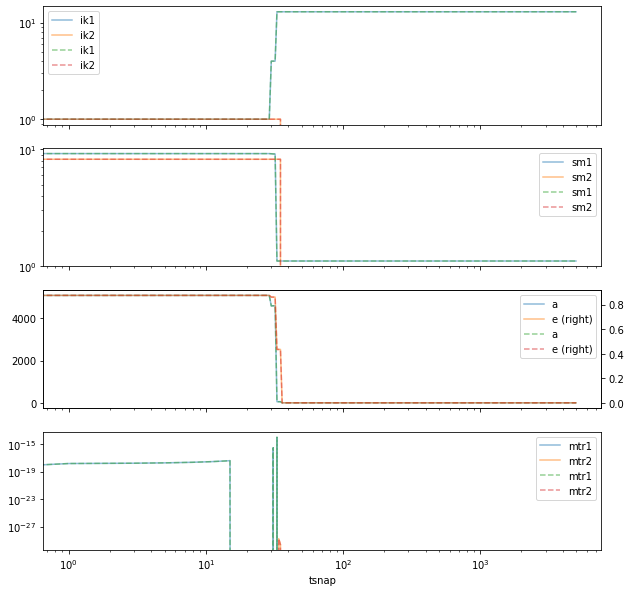

im=93; df.ikb.unique()=array([1], dtype=int8); df.ikb.unique()=array([1], dtype=int8); 


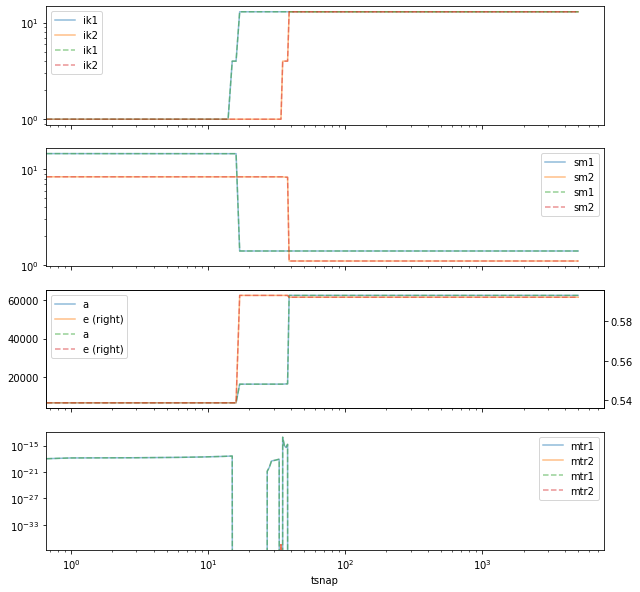

im=135; df.ikb.unique()=array([0], dtype=int8); df.ikb.unique()=array([0], dtype=int8); 


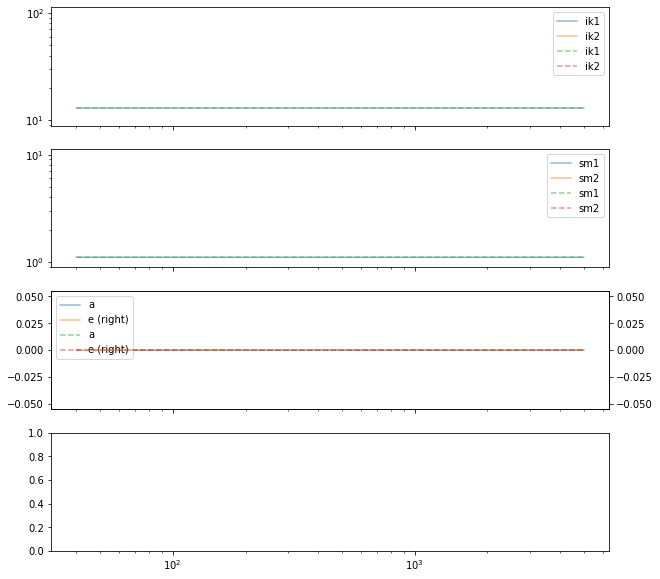

im=14; df.ikb.unique()=array([1, 0], dtype=int8); df.ikb.unique()=array([1, 0], dtype=int8); 


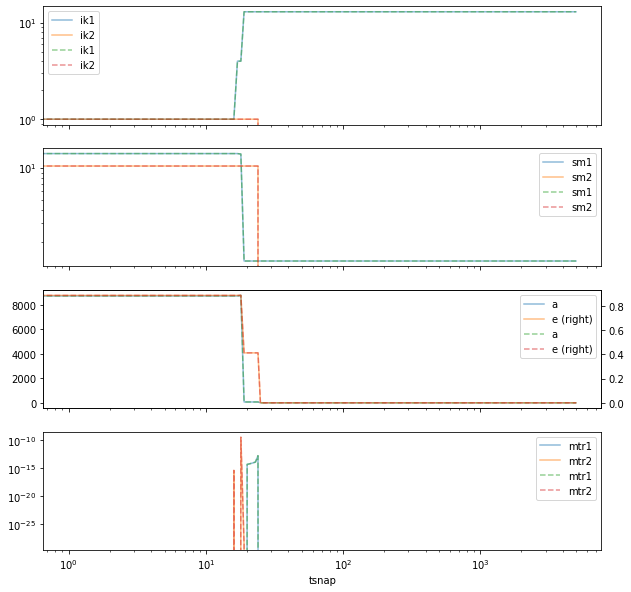

im=94; df.ikb.unique()=array([1], dtype=int8); df.ikb.unique()=array([1], dtype=int8); 


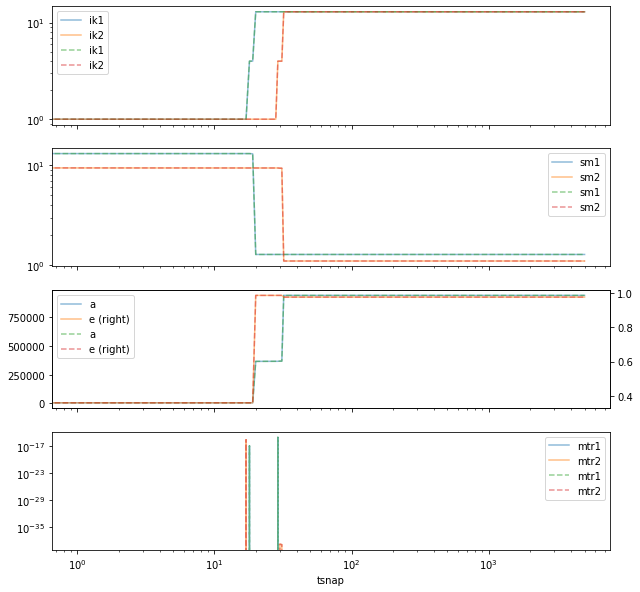

im=69; df.ikb.unique()=array([1, 0], dtype=int8); df.ikb.unique()=array([1, 0], dtype=int8); 


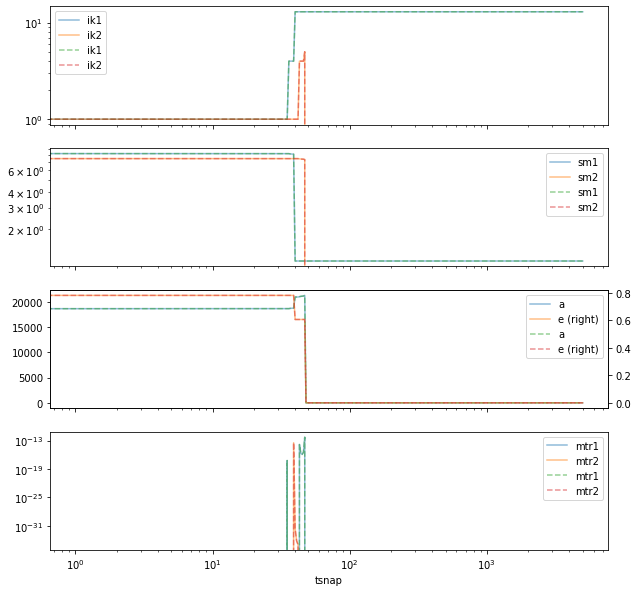

im=63; df.ikb.unique()=array([1, 0], dtype=int8); df.ikb.unique()=array([1, 0], dtype=int8); 


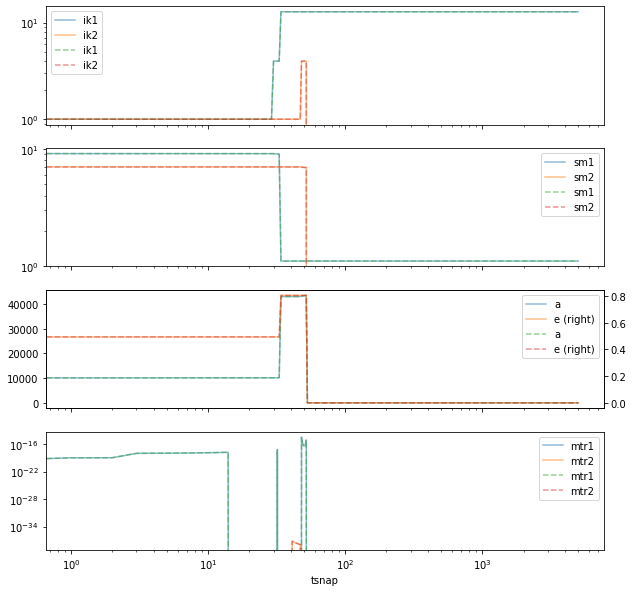

im=84; df.ikb.unique()=array([1, 0], dtype=int8); df.ikb.unique()=array([1, 0], dtype=int8); 


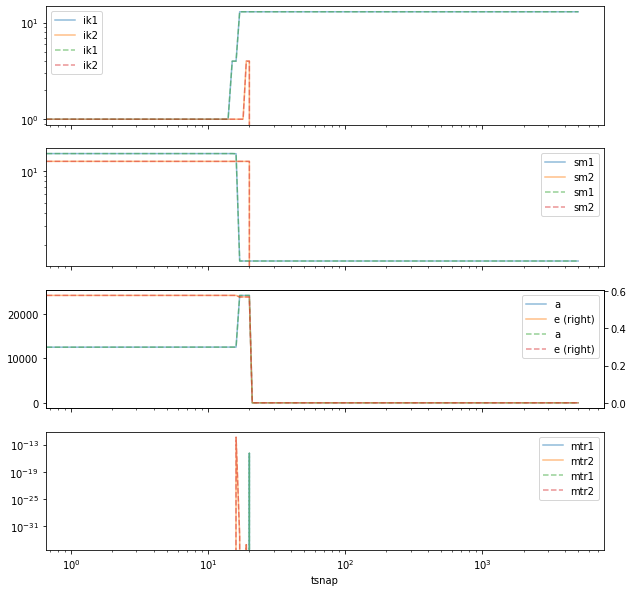

im=63; df.ikb.unique()=array([1, 0], dtype=int8); df.ikb.unique()=array([1, 0], dtype=int8); 


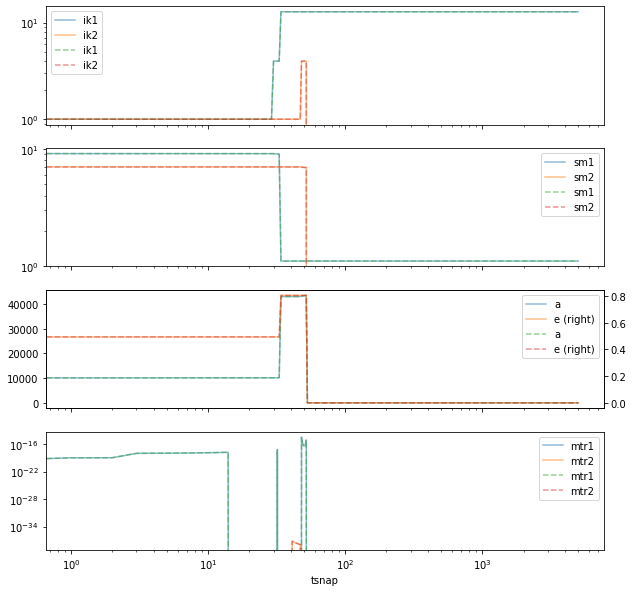

im=11; df.ikb.unique()=array([1, 0], dtype=int8); df.ikb.unique()=array([1, 0], dtype=int8); 


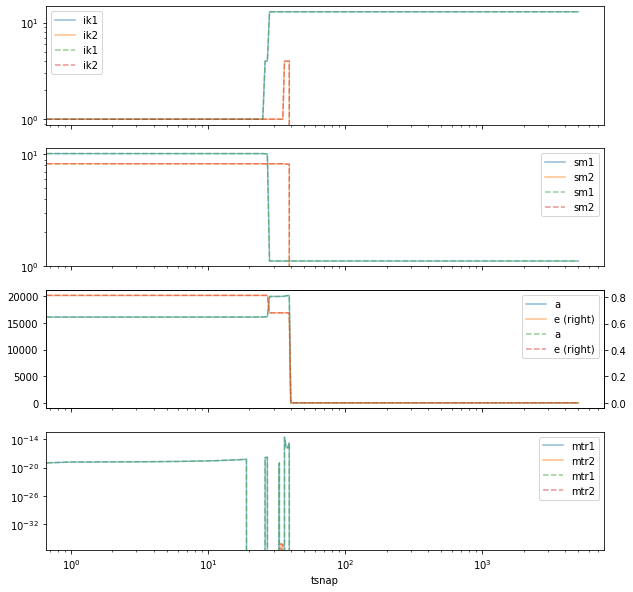

In [19]:


def show_comparison_plot(df0, df1):
    
    f, axs = plt.subplots(4, figsize=(10,10), sharex=True)
    for i, df in enumerate([df0, df1]):
        print(f"{df.ikb.unique()=}", end='; ')
        # if dfim.ikb.eq(0).all():
        #     continue
    
        df.plot(y=['ik1','ik2'], ax=axs[0], logx=True, logy=True, alpha=0.5, linestyle=('-' if i==0 else '--'))
        df.plot(y=['sm1','sm2'], ax=axs[1], logx=True, logy=True, alpha=0.5, linestyle=('-' if i==0 else '--'))
        df.plot(y=['a','e'], ax=axs[2], secondary_y='e', logx=True, alpha=0.5, linestyle=('-' if i==0 else '--'))
        if not (tmp:=df[['mtr1', 'mtr2']]).eq(0).all(None):
            df.plot(y=['mtr1','mtr2'], ax=axs[3], loglog=True, alpha=0.5, linestyle=('-' if i==0 else '--'))
    
    print()
    # df1.plot(y=['ik1','ik2'], ax=axs[0], logx=True, logy=True, alpha=0.5, linestyle='--')
    # df1.plot(y=['sm1','sm2'], ax=axs[1], logx=True, logy=True, alpha=0.5, linestyle='--')
    # df1.plot(y=['a','e'], ax=axs[2], secondary_y='e', logx=True, alpha=0.5, linestyle='--')
    # df1.plot(y=['mtr1','mtr2'], ax=axs[3], loglog=True, alpha=0.5, linestyle='--')
    plt.show()

im_l = np.random.choice(snapshot_refactoring.im.unique(), 10).tolist()
for im in im_l:
    print(f"{im=}", end='; ')
    df_ref, df_comp = get_system(im, snapshot_refactoring, snapshot_comparison)
    show_comparison_plot(df_ref, df_comp)


In [100]:
snapshot_refactoring.query('idd1==126').im.unique()

array([150], dtype=int16)

In [10]:
snapshot_refactoring.query('im==106')

,im,r,vr,vt,u,ikb,a,e,ik1,ik2,sm1,sm2,popId1,popId2,timenr,idd1,idd2,lum1,lum2,rad1,rad2,hist1,hist2,spin1,spin2,mu1,mu2,mv1,mv2,mb1,mb2,mi1,mi2,mtr1,mtr2,ibstra1,ibstra2,tsnap
1922,106,1.7057,0.31489,0.77523,-1.33080,0,0.0,0.0,1,0,11.6610,0.0,1,0,19,128,0,2.307400e+04,0.0,7.223900,0.0,100000000000000,0,1.350900e-02,0.0,-4.5755,0.0,-3.3575,0.0,-3.6172,0.0,-3.0984,0.0,0.0,0.0,0,0,19
2029,106,1.7057,0.31489,0.77523,-1.25230,0,0.0,0.0,1,0,11.6600,0.0,1,0,20,128,0,2.490400e+04,0.0,8.546800,0.0,100000000000000,0,1.064100e-02,0.0,-4.7712,0.0,-3.5958,0.0,-3.8445,0.0,-3.3512,0.0,0.0,0.0,0,0,20
2136,106,1.7057,0.31489,0.77523,-1.21830,0,0.0,0.0,4,0,11.6540,0.0,1,0,21,128,0,4.456800e+04,0.0,31.742000,0.0,100000000000000,0,1.615500e-03,0.0,-6.2940,0.0,-5.5023,0.0,-5.6506,0.0,-5.3854,0.0,0.0,0.0,0,0,21
2244,106,1.7057,0.31489,0.77523,-1.18640,0,0.0,0.0,4,0,11.6470,0.0,1,0,22,128,0,5.016600e+04,0.0,61.537000,0.0,100000000000000,0,5.188700e-04,0.0,-6.8260,0.0,-6.3383,0.0,-6.4102,0.0,-6.3194,0.0,0.0,0.0,0,0,22
2353,106,1.7057,0.31489,0.77523,-1.09310,0,0.0,0.0,13,0,1.1869,0.0,1,0,23,128,0,1.076500e-01,0.0,0.000014,0.0,100000000000000,0,4.469800e+09,0.0,19.2050,0.0,21.1890,0.0,20.6970,0.0,21.6730,0.0,0.0,0.0,0,0,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772470,106,1.7057,0.31489,0.77523,-0.17814,0,0.0,0.0,13,0,1.1869,0.0,1,0,4996,128,0,9.069400e-10,0.0,0.000014,0.0,100000000000000,0,6.223800e+09,0.0,27.6250,0.0,27.5660,0.0,27.7390,0.0,27.3910,0.0,0.0,0.0,0,0,4996
772625,106,1.7057,0.31489,0.77523,-0.17814,0,0.0,0.0,13,0,1.1869,0.0,1,0,4997,128,0,9.065700e-10,0.0,0.000014,0.0,100000000000000,0,6.223800e+09,0.0,27.6260,0.0,27.5660,0.0,27.7390,0.0,27.3910,0.0,0.0,0.0,0,0,4997
772780,106,1.7057,0.31489,0.77523,-0.17814,0,0.0,0.0,13,0,1.1869,0.0,1,0,4998,128,0,9.062100e-10,0.0,0.000014,0.0,100000000000000,0,6.223800e+09,0.0,27.6260,0.0,27.5670,0.0,27.7390,0.0,27.3910,0.0,0.0,0.0,0,0,4998
772935,106,1.7057,0.31489,0.77523,-0.17814,0,0.0,0.0,13,0,1.1869,0.0,1,0,4999,128,0,9.058400e-10,0.0,0.000014,0.0,100000000000000,0,6.223800e+09,0.0,27.6260,0.0,27.5670,0.0,27.7400,0.0,27.3920,0.0,0.0,0.0,0,0,4999


In [10]:
import astropy

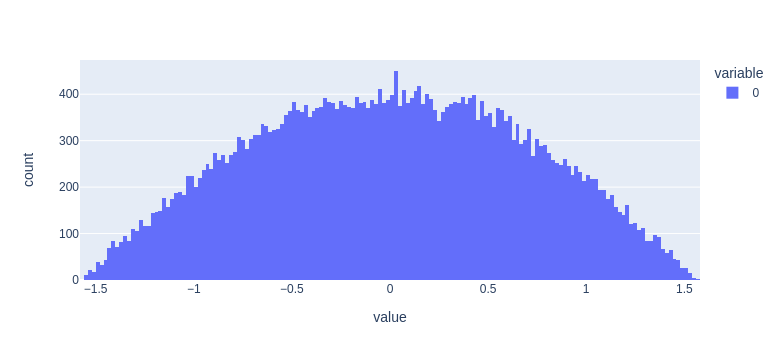

In [20]:
from astropy.coordinates import uniform_spherical_random_surface
y = [x.lat.value for x in uniform_spherical_random_surface(40000)]
px.histogram(y)

In [16]:
import plotly.express as px

In [14]:
uniform_spherical_random_surface(4)

<UnitSphericalRepresentation (lon, lat) in rad
    [(3.60546533,  0.45323193), (5.50114623, -0.00084482),
     (1.89864777,  0.46251816), (4.44090042, -0.27519471)]>

In [12]:
# DEPRICATED
# files are now edited on chuck

logger.setLevel(20)

logger.info("Coping files")
cmd = ("cd /home/gwiktoro/camk/mocca/src && "
       "rsync -avzt --exclude '*.dat' --exclude '*.o' "
           "--exclude '*.mod' --exclude '*.h' --exclude '*.ini' "  # if not ini here then it would overwrite the ini file in testing folders
           ". camk:/work/chuck/mocca/gwiktoro/refactoring/devel_bse/src"
      )
p_copy = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE)

print(p_copy.stdout.decode())

if p_copy.returncode != 0:
    logger.error(f"{p_copy.returncode=}\n{p_copy.stderr.decode()}")